# Sistema de Gestão de Riscos Corporativos — EDA & KRIs
**Stack Microsoft: SAP · Azure Forms · Power Automate · Microsoft Fabric · Power BI**
**Framework: COSO ERM + ISO 31000**

Rafael Reghine Munhoz | MBA Data Science & Analytics — USP

---
## Contexto
Grande empresa industrial com stack Microsoft. Dados capturados via **Azure Forms** e
integrados ao banco via **Power Automate**. Analytics entregue no **Power BI** via
**Microsoft Fabric Lakehouse**. ERP: **SAP** (MM, PM, FI, HR, QM, PP, SD).

In [5]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif", "axes.titlesize": 13, "axes.labelsize": 11,
})

PALETTE = {
    "Baixo":"#3B9E6B","Médio":"#E8A83E","Alto":"#E07B39","Crítico":"#C0392B",
    "Eficaz":"#3B9E6B","Parcial":"#E8A83E","Ineficaz":"#C0392B","Não testado":"#95a5a6",
    "Normal":"#3B9E6B","Atenção":"#E8A83E",
}
MICROSOFT_BLUE = "#0078D4"   # Azure blue

DB_PATH = Path("data/risk_management.db")
conn    = sqlite3.connect(DB_PATH)

def q(sql): return pd.read_sql_query(sql, conn)

Path("outputs").mkdir(exist_ok=True)

# Carregar tabelas
risks    = q("SELECT r.*, a.name AS area, a.department FROM risks r LEFT JOIN areas a ON r.area_id=a.id")
occs     = q("""SELECT o.*, a.name AS area, r.title AS risk_title, r.risk_category, r.risk_level
                FROM occurrences o
                LEFT JOIN areas a ON o.area_id=a.id
                LEFT JOIN risks r ON o.risk_id=r.id""")
actions  = q("SELECT ap.*, a.name AS area FROM action_plans ap LEFT JOIN areas a ON ap.area_id=a.id")
controls = q("SELECT rc.*, r.risk_category FROM risk_controls rc LEFT JOIN risks r ON rc.risk_id=r.id")
audits   = q("SELECT au.*, a.name AS area FROM audits au LEFT JOIN areas a ON au.area_id=a.id")
kri_hist = q("SELECT kh.*, a.name AS area FROM kri_history kh LEFT JOIN areas a ON kh.area_id=a.id")

print(f"Riscos: {len(risks)} | Ocorrências: {len(occs)} | Ações: {len(actions)}")
print(f"Controles: {len(controls)} | Auditorias: {len(audits)} | KRI History: {len(kri_hist)}")

Riscos: 116 | Ocorrências: 320 | Ações: 240
Controles: 232 | Auditorias: 80 | KRI History: 432


## 1. Portfólio de Riscos — COSO ERM

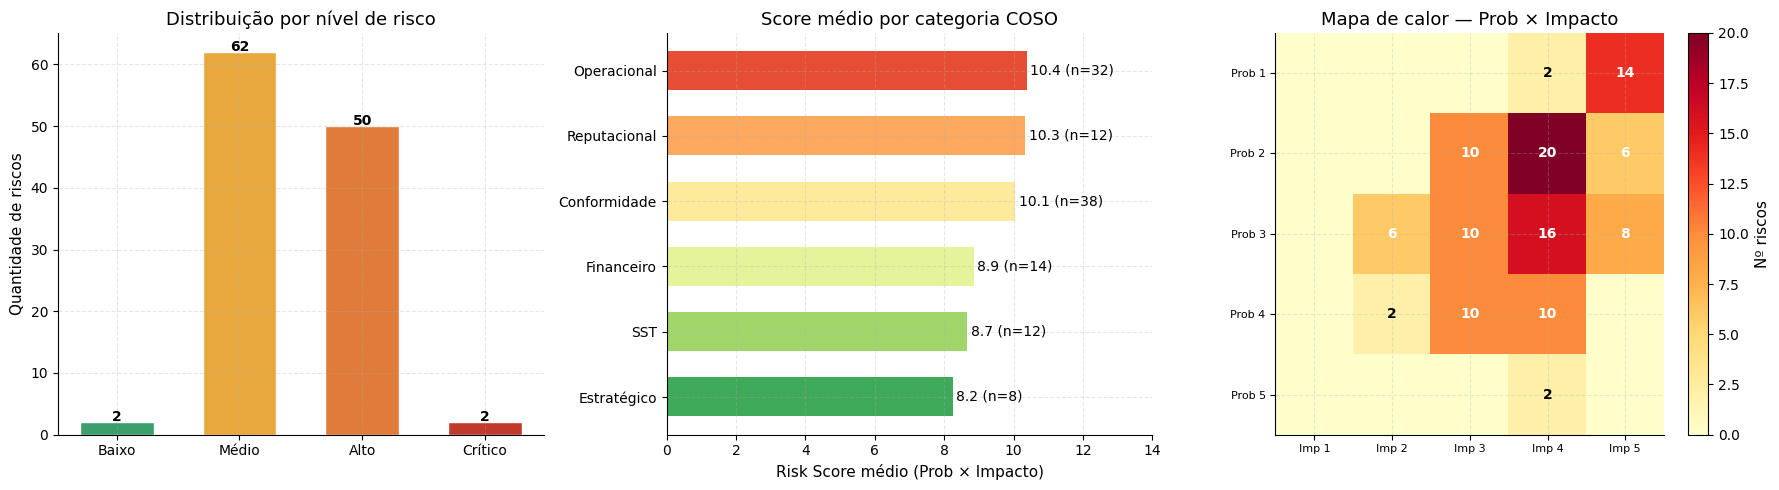

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Nível de risco
level_order  = ["Baixo","Médio","Alto","Crítico"]
level_counts = risks["risk_level"].value_counts().reindex(level_order, fill_value=0)
bars = axes[0].bar(level_order, level_counts.values,
                   color=[PALETTE[l] for l in level_order], edgecolor="white", width=0.6)
for bar, val in zip(bars, level_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 str(val), ha="center", fontweight="bold")
axes[0].set_title("Distribuição por nível de risco")
axes[0].set_ylabel("Quantidade de riscos")

# Categoria COSO
cat_score = (risks.groupby("risk_category")["risk_score"]
             .agg(["mean","count"]).sort_values("mean", ascending=True))
clrs = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(cat_score)))
bars2 = axes[1].barh(cat_score.index, cat_score["mean"], color=clrs, height=0.6)
for bar, (_, row) in zip(bars2, cat_score.iterrows()):
    axes[1].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f"{row['mean']:.1f} (n={int(row['count'])})", va="center", fontsize=10)
axes[1].set_title("Score médio por categoria COSO")
axes[1].set_xlabel("Risk Score médio (Prob × Impacto)")
axes[1].set_xlim(0, cat_score["mean"].max()*1.35)

# Heatmap prob × impacto
hm = risks.groupby(["probability","impact"]).size().unstack(fill_value=0)
hm = hm.reindex(index=range(1,6), columns=range(1,6), fill_value=0)
im = axes[2].imshow(hm.values, cmap="YlOrRd", aspect="auto")
axes[2].set_xticks(range(5)); axes[2].set_yticks(range(5))
axes[2].set_xticklabels([f"Imp {i}" for i in range(1,6)], fontsize=8)
axes[2].set_yticklabels([f"Prob {i}" for i in range(1,6)], fontsize=8)
axes[2].set_title("Mapa de calor — Prob × Impacto")
for i in range(5):
    for j in range(5):
        v = hm.values[i,j]
        if v > 0:
            axes[2].text(j, i, str(v), ha="center", va="center",
                         fontweight="bold", color="white" if v>2 else "black")
plt.colorbar(im, ax=axes[2], label="Nº riscos")
plt.tight_layout()
plt.savefig("outputs/01_risk_portfolio.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Canal de Captura — Azure Forms vs SAP vs Manual

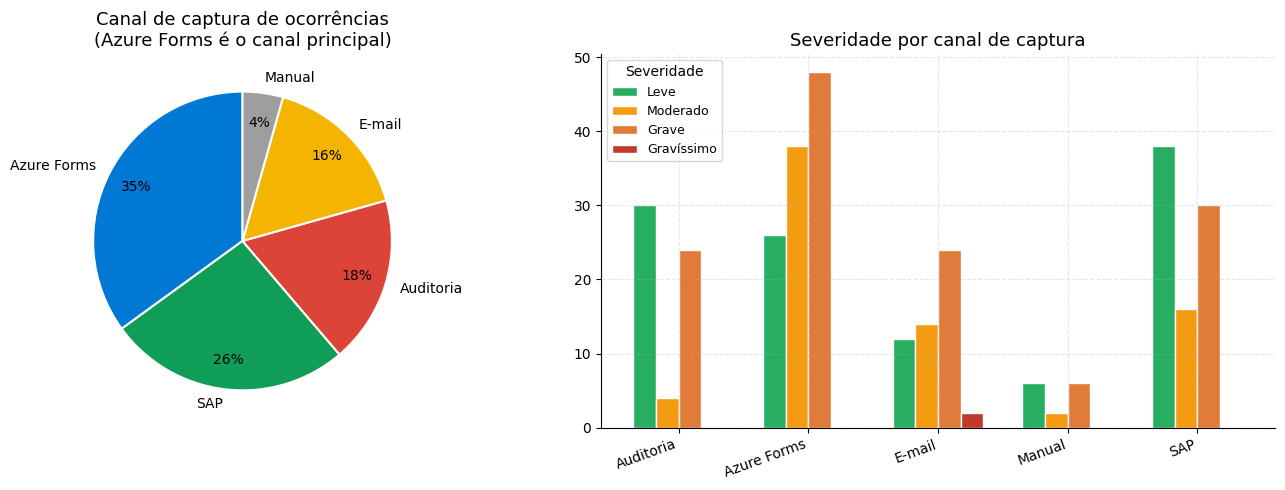

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ocorrências por canal
ch_counts = occs["capture_channel"].value_counts()
colors_ch = [MICROSOFT_BLUE if "Azure" in c else "#0F9D58" if c=="SAP"
             else "#F4B400" if c=="E-mail" else "#DB4437" if c=="Auditoria"
             else "#9E9E9E" for c in ch_counts.index]
axes[0].pie(ch_counts.values, labels=ch_counts.index, autopct="%1.0f%%",
            colors=colors_ch, startangle=90, pctdistance=0.8,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[0].set_title("Canal de captura de ocorrências\n(Azure Forms é o canal principal)")

# Severidade por canal
sev_by_ch = occs.groupby(["capture_channel","severity"]).size().unstack(fill_value=0)
sev_order  = ["Leve","Moderado","Grave","Gravíssimo"]
sev_colors = ["#27AE60","#F39C12","#E07B39","#C0392B"]
for col in sev_order:
    if col not in sev_by_ch.columns:
        sev_by_ch[col] = 0
sev_by_ch[sev_order].plot(kind="bar", ax=axes[1],
                           color=sev_colors, edgecolor="white", width=0.7)
axes[1].set_title("Severidade por canal de captura")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")
axes[1].legend(title="Severidade", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/02_capture_channel.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Análise por Área Corporativa

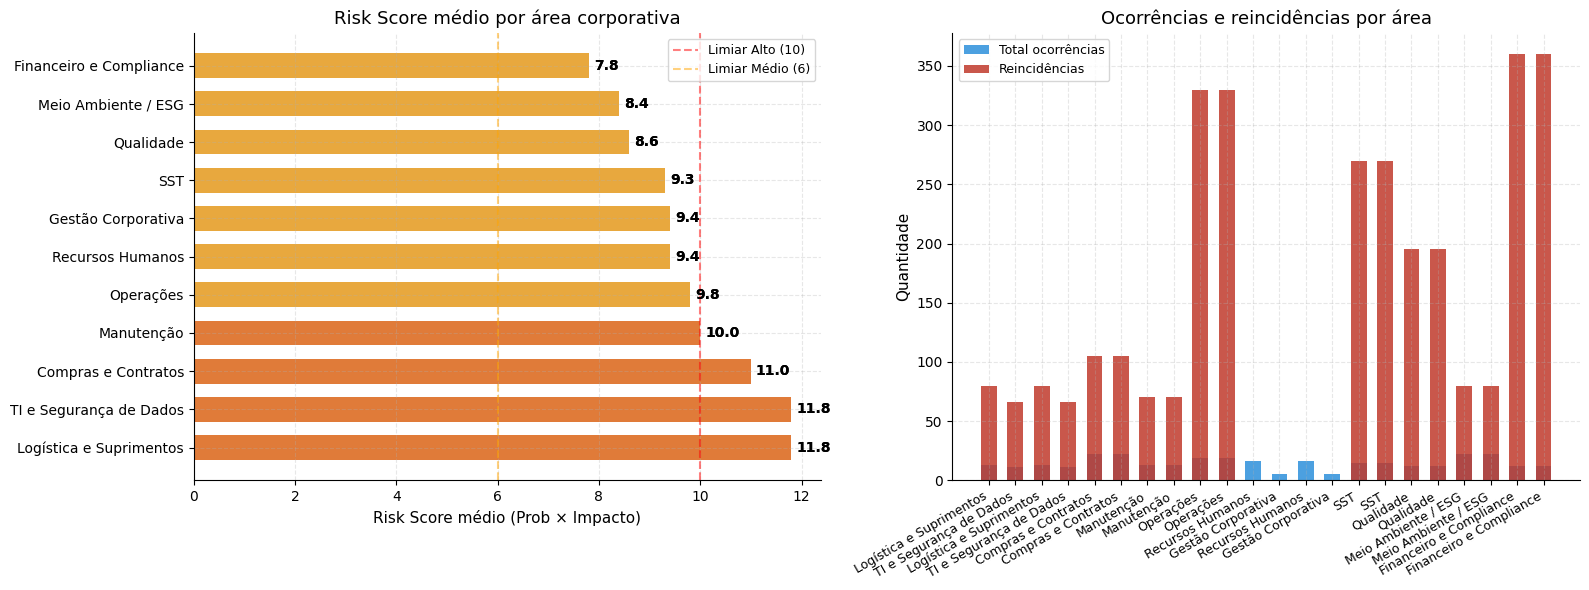

In [8]:
area_summary = q("""
    SELECT a.name AS area, a.department,
           COUNT(DISTINCT r.id) AS total_risks,
           ROUND(AVG(r.risk_score),1) AS avg_score,
           SUM(CASE WHEN r.risk_level='Crítico' THEN 1 ELSE 0 END) AS critical,
           SUM(CASE WHEN r.risk_level='Alto'    THEN 1 ELSE 0 END) AS high,
           COUNT(DISTINCT o.id) AS occurrences,
           SUM(CASE WHEN o.is_recurrence=1 THEN 1 ELSE 0 END) AS recurrences,
           COUNT(DISTINCT ap.id) AS actions,
           SUM(CASE WHEN ap.status='Vencido' THEN 1 ELSE 0 END) AS overdue
    FROM areas a
    LEFT JOIN risks r ON r.area_id=a.id
    LEFT JOIN occurrences o ON o.area_id=a.id
    LEFT JOIN action_plans ap ON ap.area_id=a.id
    GROUP BY a.id ORDER BY avg_score DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Score médio por área
clrs_area = ["#C0392B" if s>=15 else "#E07B39" if s>=10 else "#E8A83E" if s>=6 else "#3B9E6B"
             for s in area_summary["avg_score"]]
bars = axes[0].barh(area_summary["area"], area_summary["avg_score"],
                    color=clrs_area, height=0.65)
axes[0].axvline(10, color="red", linestyle="--", alpha=0.5, label="Limiar Alto (10)")
axes[0].axvline(6, color="orange", linestyle="--", alpha=0.5, label="Limiar Médio (6)")
axes[0].set_title("Risk Score médio por área corporativa")
axes[0].set_xlabel("Risk Score médio (Prob × Impacto)")
axes[0].legend(fontsize=9)
for bar, val in zip(bars, area_summary["avg_score"]):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f"{val}", va="center", fontweight="bold", fontsize=10)

# Ocorrências e reincidências por área
x = range(len(area_summary))
axes[1].bar(x, area_summary["occurrences"], color=MICROSOFT_BLUE, alpha=0.7,
            label="Total ocorrências", width=0.6)
axes[1].bar(x, area_summary["recurrences"], color="#C0392B", alpha=0.85,
            label="Reincidências", width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(area_summary["area"], rotation=30, ha="right", fontsize=9)
axes[1].set_title("Ocorrências e reincidências por área")
axes[1].set_ylabel("Quantidade")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/03_area_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Controles — Eficácia e Automação (SAP / Power Automate)

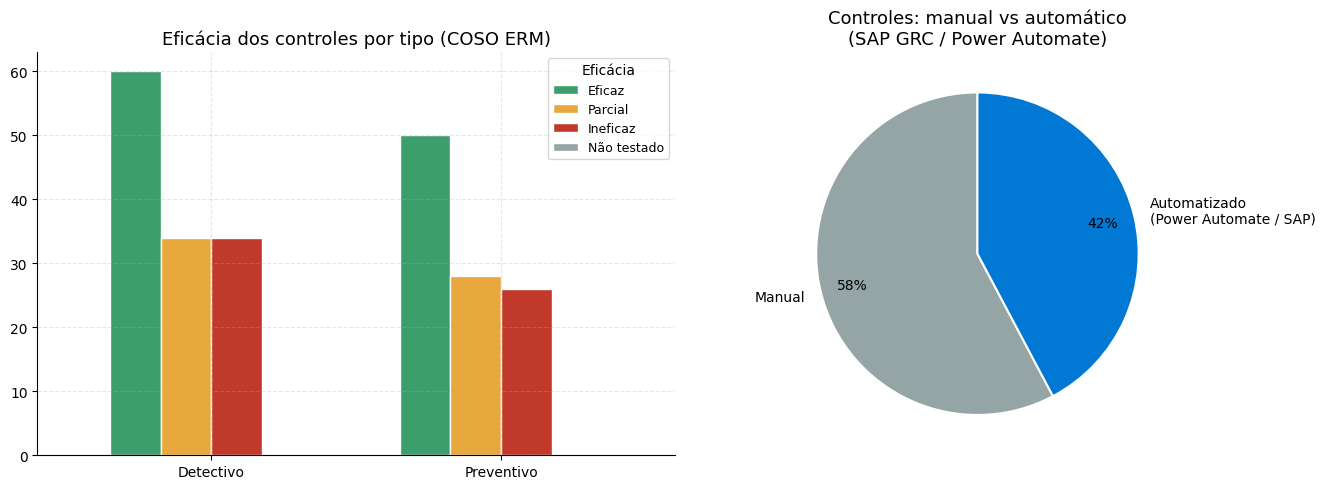

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eficácia por tipo de controle
eff_order = ["Eficaz","Parcial","Ineficaz","Não testado"]
eff_colors_list = [PALETTE[e] for e in eff_order]
eff_by_type = controls.groupby(["control_type","effectiveness"]).size().unstack(fill_value=0)
for col in eff_order:
    if col not in eff_by_type.columns:
        eff_by_type[col] = 0
eff_by_type[eff_order].plot(kind="bar", ax=axes[0],
                             color=eff_colors_list, edgecolor="white", width=0.7)
axes[0].set_title("Eficácia dos controles por tipo (COSO ERM)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title="Eficácia", fontsize=9)
axes[0].set_xlabel("")

# Automação: manual vs automático (Power Automate / SAP)
auto_counts = controls["is_automated"].value_counts()
labels = ["Manual","Automatizado\n(Power Automate / SAP)"]
colors_a = ["#95a5a6", MICROSOFT_BLUE]
vals = [auto_counts.get(0,0), auto_counts.get(1,0)]
wedges, texts, autos = axes[1].pie(vals, labels=labels, autopct="%1.0f%%",
                                    colors=colors_a, startangle=90, pctdistance=0.8,
                                    wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[1].set_title("Controles: manual vs automático\n(SAP GRC / Power Automate)")
plt.tight_layout()
plt.savefig("outputs/04_controls.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Auditorias — 6 tipos, score de conformidade

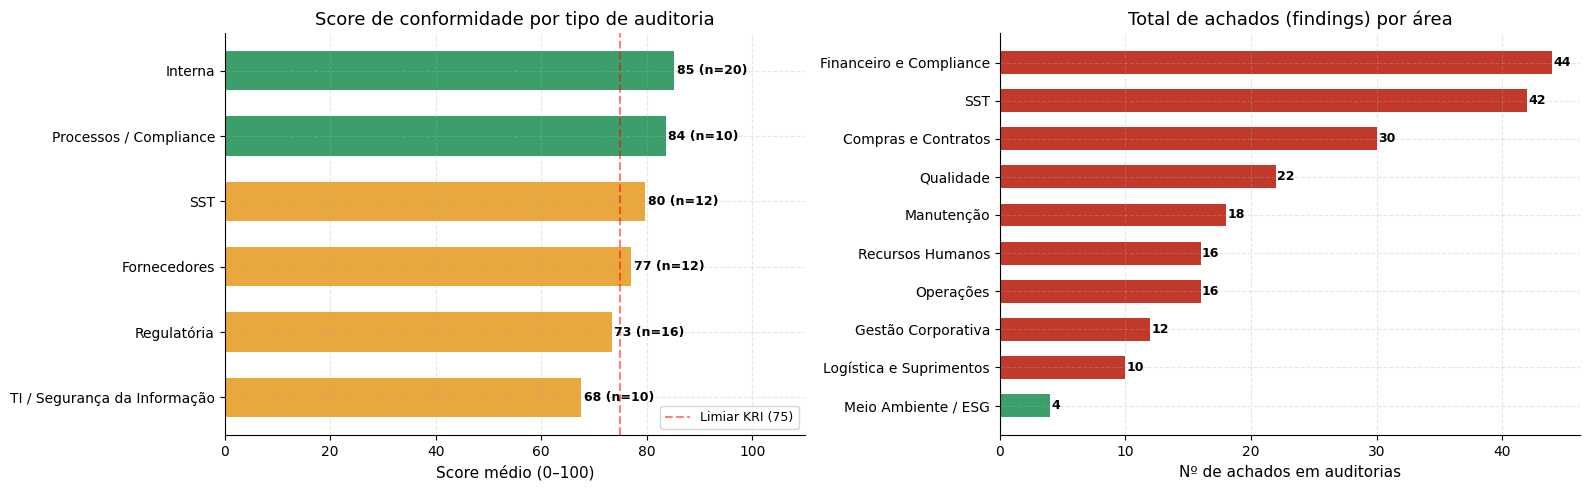

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Score médio por tipo de auditoria
audit_score = (audits.groupby("audit_type")
               .agg(score=("conformity_score","mean"),
                    findings=("findings_count","sum"),
                    n=("id","count"))
               .sort_values("score", ascending=True))
clrs_aud = ["#C0392B" if s<65 else "#E8A83E" if s<80 else "#3B9E6B"
            for s in audit_score["score"]]
bars = axes[0].barh(audit_score.index, audit_score["score"],
                    color=clrs_aud, height=0.6)
axes[0].axvline(75, color="red", linestyle="--", alpha=0.5, label="Limiar KRI (75)")
axes[0].set_xlim(0, 110)
axes[0].set_title("Score de conformidade por tipo de auditoria")
axes[0].set_xlabel("Score médio (0–100)")
axes[0].legend(fontsize=9)
for bar, val, n in zip(bars, audit_score["score"], audit_score["n"]):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 f"{val:.0f} (n={n})", va="center", fontsize=9, fontweight="bold")

# Achados por área
findings_area = (audits.groupby("area")["findings_count"]
                 .sum().sort_values(ascending=True))
colors_f = ["#C0392B" if v>8 else "#E8A83E" if v>4 else "#3B9E6B"
            for v in findings_area.values]
bars2 = axes[1].barh(findings_area.index, findings_area.values,
                     color=colors_f, height=0.6)
axes[1].set_title("Total de achados (findings) por área")
axes[1].set_xlabel("Nº de achados em auditorias")
for bar, val in zip(bars2, findings_area.values):
    axes[1].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 str(val), va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/05_audits.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Planos de Ação — Tratamento do Risco (ISO 31000)

C:\Users\User\AppData\Local\Temp\ipykernel_7048\508891817.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(st_order, rotation=15, ha="right")


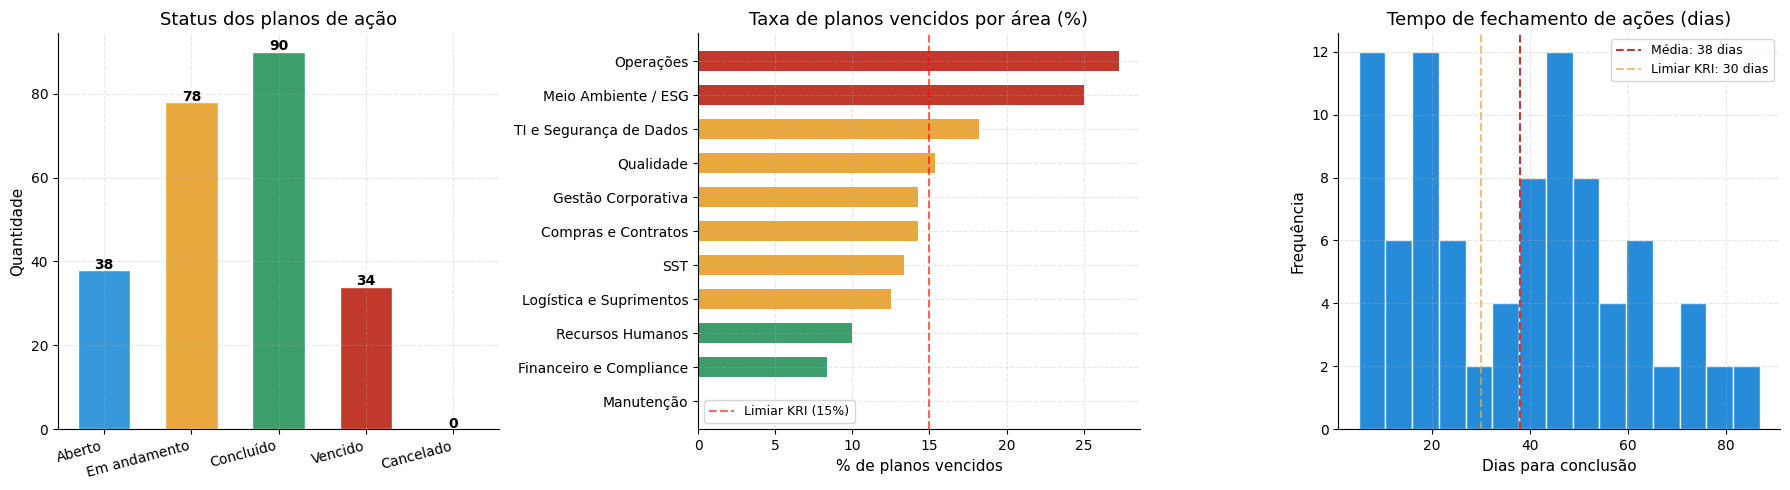

In [11]:
actions["deadline"]  = pd.to_datetime(actions["deadline"])
actions["opened_at"] = pd.to_datetime(actions["opened_at"])
actions["closed_at"] = pd.to_datetime(actions["closed_at"])
closed_acts = actions[actions["status"]=="Concluído"].copy()
closed_acts["days_to_close"] = (closed_acts["closed_at"] - closed_acts["opened_at"]).dt.days

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Status
st_order  = ["Aberto","Em andamento","Concluído","Vencido","Cancelado"]
st_colors = ["#3498DB","#E8A83E","#3B9E6B","#C0392B","#95a5a6"]
st_counts = actions["status"].value_counts().reindex(st_order, fill_value=0)
bars = axes[0].bar(st_order, st_counts.values, color=st_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, st_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(val), ha="center", fontweight="bold")
axes[0].set_title("Status dos planos de ação")
axes[0].set_xticklabels(st_order, rotation=15, ha="right")
axes[0].set_ylabel("Quantidade")

# Overdue por área
overdue_area = (actions.groupby("area")
                .agg(total=("status","count"),
                     vencidos=("status", lambda x:(x=="Vencido").sum()))
                .assign(taxa=lambda d: d["vencidos"]/d["total"]*100)
                .sort_values("taxa", ascending=True))
clrs_od = ["#C0392B" if t>20 else "#E8A83E" if t>10 else "#3B9E6B"
           for t in overdue_area["taxa"]]
axes[1].barh(overdue_area.index, overdue_area["taxa"], color=clrs_od, height=0.6)
axes[1].axvline(15, color="red", linestyle="--", alpha=0.6, label="Limiar KRI (15%)")
axes[1].set_title("Taxa de planos vencidos por área (%)")
axes[1].set_xlabel("% de planos vencidos")
axes[1].legend(fontsize=9)

# Tempo de fechamento
if len(closed_acts) > 0:
    axes[2].hist(closed_acts["days_to_close"].dropna(), bins=15,
                 color=MICROSOFT_BLUE, edgecolor="white", alpha=0.85)
    mean_d = closed_acts["days_to_close"].mean()
    axes[2].axvline(mean_d, color="#C0392B", linestyle="--",
                    label=f"Média: {mean_d:.0f} dias")
    axes[2].axvline(30, color="#E8A83E", linestyle="--", alpha=0.7,
                    label="Limiar KRI: 30 dias")
    axes[2].set_title("Tempo de fechamento de ações (dias)")
    axes[2].set_xlabel("Dias para conclusão")
    axes[2].set_ylabel("Frequência")
    axes[2].legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/06_action_plans.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. KRIs — Dashboard de Indicadores-Chave

KRIs são métricas **forward-looking** — sinalizam risco antes da materialização.
Calculados automaticamente via SQL + Python e entregues no **Power BI via Microsoft Fabric**.

C:\Users\User\AppData\Local\Temp\ipykernel_7048\921125394.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


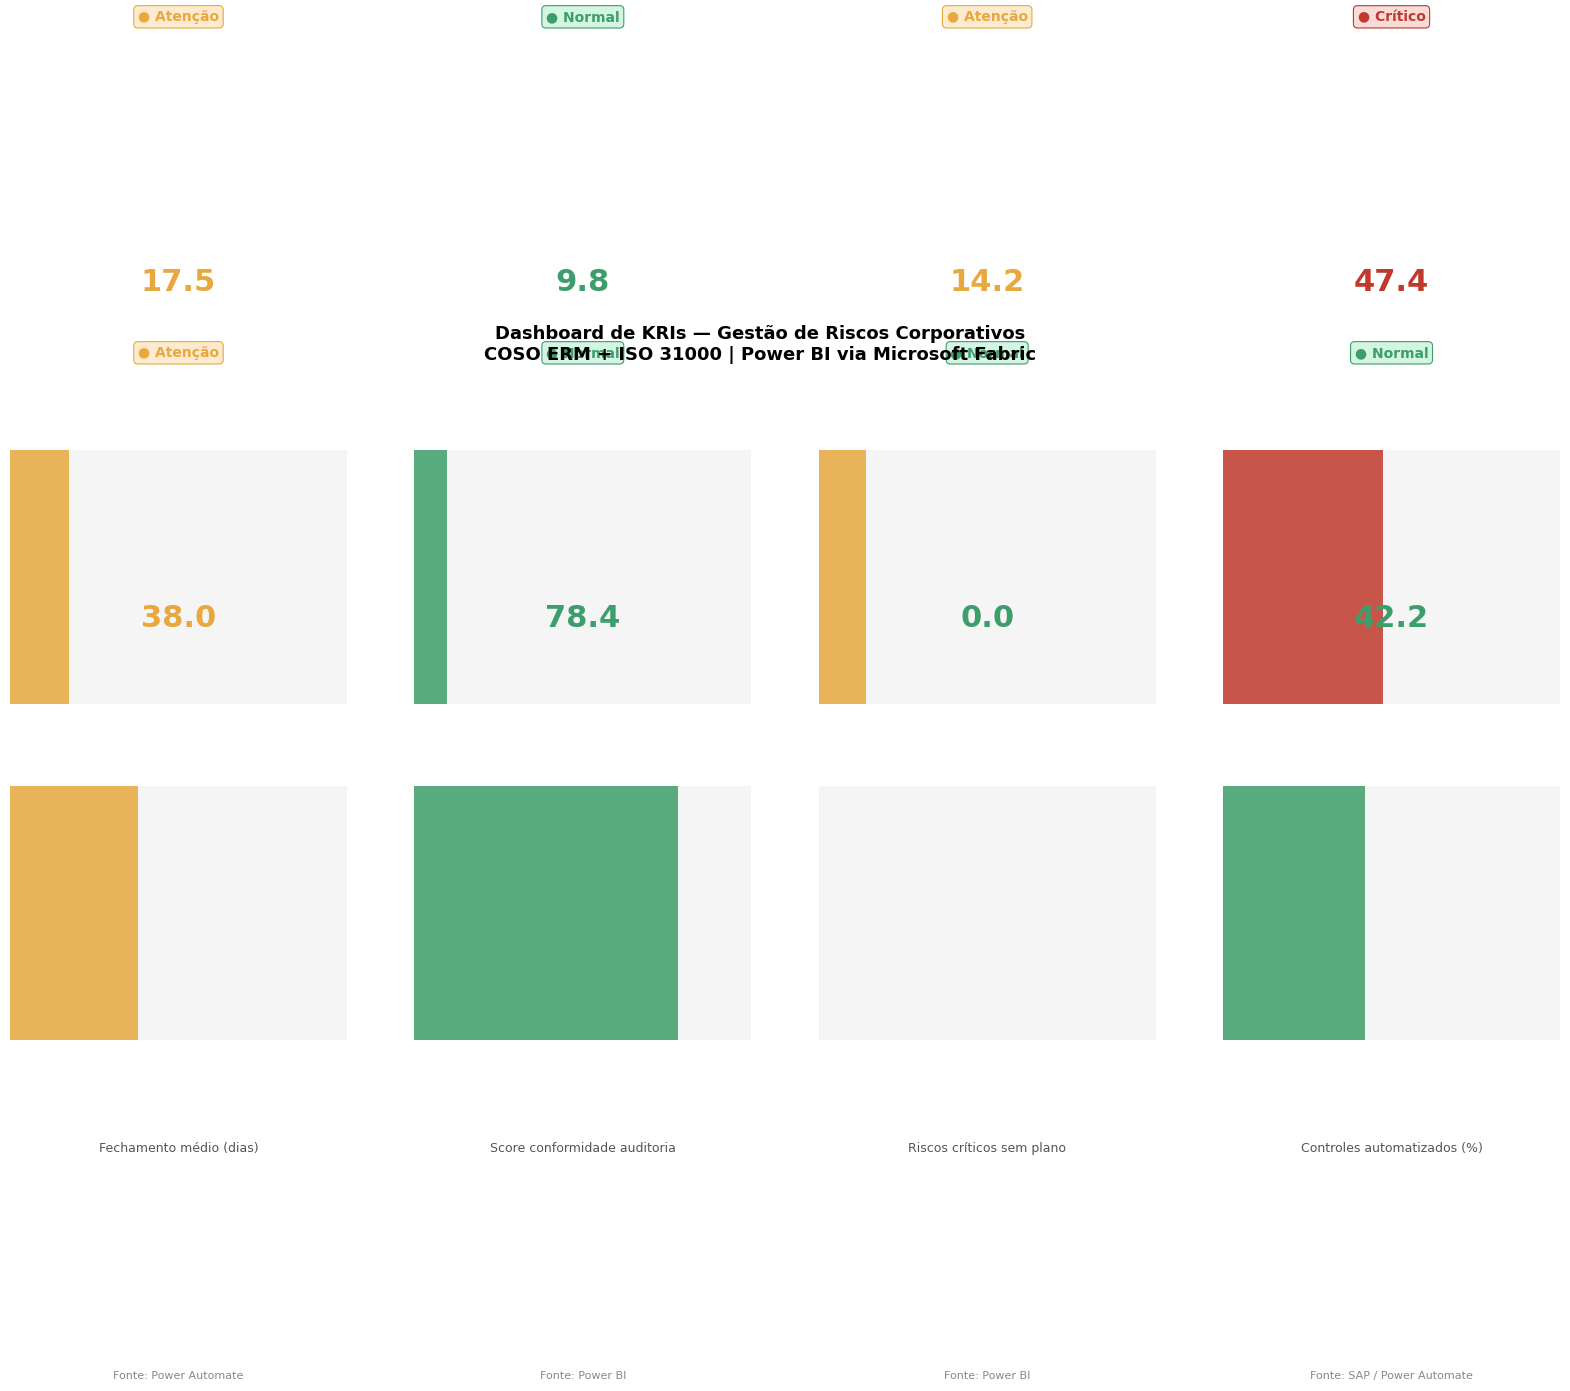


📊 RESUMO DE KRIs
KRI                                       Valor  Fonte                  Status
-----------------------------------------------------------------
Taxa de reincidência (%)                  17.5  Azure Forms            🟡 Atenção
Score médio de risco                       9.8  Power BI               🟢 Normal
Planos vencidos (%)                       14.2  Power Automate         🟡 Atenção
Controles eficazes (%)                    47.4  SAP GRC                🔴 Crítico
Fechamento médio (dias)                   38.0  Power Automate         🟡 Atenção
Score conformidade auditoria              78.4  Power BI               🟢 Normal
Riscos críticos sem plano                  0.0  Power BI               🟢 Normal
Controles automatizados (%)               42.2  SAP / Power Automate   🟢 Normal


In [12]:
today_ts = pd.Timestamp.today()
STATUS_COLOR = {"Normal":"#3B9E6B","Atenção":"#E8A83E","Crítico":"#C0392B"}

def kri_badge(val, warn, crit, invert=False):
    if invert:
        st = "Crítico" if val < crit else "Atenção" if val < warn else "Normal"
    else:
        st = "Crítico" if val > crit else "Atenção" if val > warn else "Normal"
    return st

recur_rate   = occs["is_recurrence"].mean() * 100
avg_score    = risks["risk_score"].mean()
overdue_rate = (actions["status"]=="Vencido").mean() * 100
eff_rate     = (controls["effectiveness"]=="Eficaz").mean() * 100
avg_audit    = audits["conformity_score"].mean()
n_crit_no_plan = len(set(risks[risks["risk_level"]=="Crítico"]["id"]) - set(actions["risk_id"].dropna().astype(int)))
avg_close_d  = closed_acts["days_to_close"].mean() if len(closed_acts) > 0 else 0
auto_rate    = controls["is_automated"].mean() * 100

kris = [
    ("Taxa de reincidência (%)",        recur_rate,   15, 25,  False, "Azure Forms"),
    ("Score médio de risco",            avg_score,    12, 18,  False, "Power BI"),
    ("Planos vencidos (%)",             overdue_rate, 10, 20,  False, "Power Automate"),
    ("Controles eficazes (%)",          eff_rate,     70, 50,  True,  "SAP GRC"),
    ("Fechamento médio (dias)",         avg_close_d,  30, 60,  False, "Power Automate"),
    ("Score conformidade auditoria",    avg_audit,    75, 60,  True,  "Power BI"),
    ("Riscos críticos sem plano",       n_crit_no_plan, 0, 2,  False, "Power BI"),
    ("Controles automatizados (%)",     auto_rate,    40, 20,  True,  "SAP / Power Automate"),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
badge_bg = {"Normal":"#D5F5E3","Atenção":"#FDEBD0","Crítico":"#FADBD8"}

for i, (name, val, warn, crit, invert, source) in enumerate(kris):
    ax  = axes[i]
    st  = kri_badge(val, warn, crit, invert)
    col = STATUS_COLOR[st]
    pct = min(abs(val), 100)
    ax.barh([0], [100], color="#f5f5f5", height=0.5)
    ax.barh([0], [pct], color=col, height=0.5, alpha=0.85)
    ax.set_xlim(0, 100); ax.set_yticks([]); ax.set_xticks([])
    ax.spines[:].set_visible(False)
    ax.text(50, 0.55, f"{val:.1f}", ha="center", va="bottom",
            fontsize=22, fontweight="bold", color=col)
    ax.text(50, -0.45, name, ha="center", va="top", fontsize=9, color="#555")
    ax.text(50, -0.9, f"Fonte: {source}", ha="center", va="top", fontsize=8, color="#888")
    ax.text(50, 1.1, f"● {st}", ha="center", va="center", fontsize=10,
            fontweight="bold", color=col,
            bbox=dict(boxstyle="round,pad=0.3", facecolor=badge_bg[st],
                      edgecolor=col, linewidth=0.8))

plt.suptitle("Dashboard de KRIs — Gestão de Riscos Corporativos\nCOSO ERM + ISO 31000 | Power BI via Microsoft Fabric",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/07_kri_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 RESUMO DE KRIs\n" + "="*65)
print(f"{'KRI':<38} {'Valor':>8}  {'Fonte':<22} {'Status'}")
print("-"*65)
for name, val, warn, crit, invert, source in kris:
    st   = kri_badge(val, warn, crit, invert)
    icon = "🟢" if st=="Normal" else "🟡" if st=="Atenção" else "🔴"
    print(f"{name:<38} {val:>7.1f}  {source:<22} {icon} {st}")

## 8. Tendência de KRIs — Série Histórica (18 meses)
Dados do `kri_history` — gerado automaticamente e atualizado mensalmente via Power Automate.

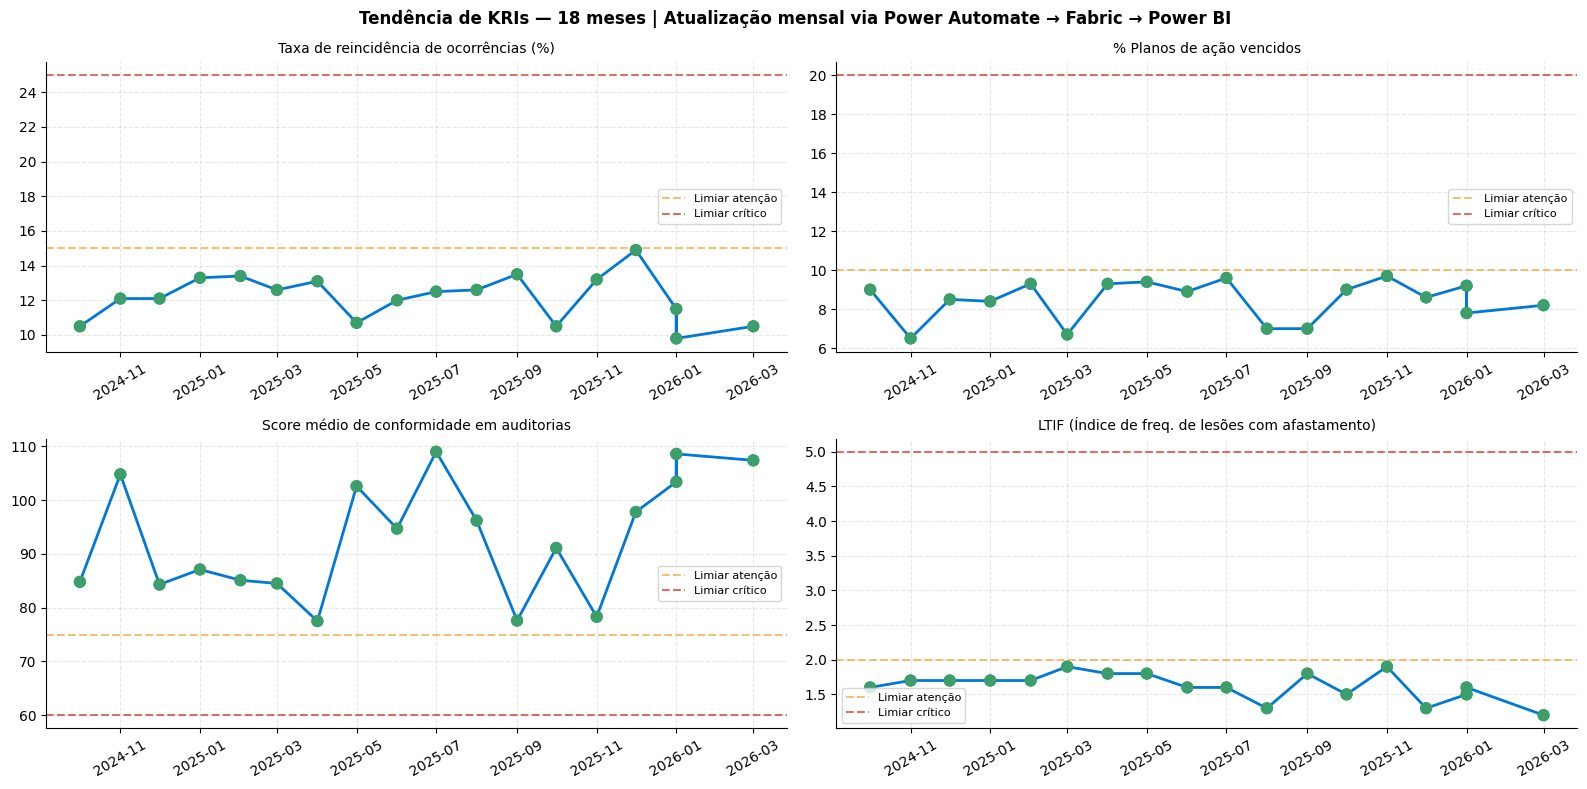

In [13]:
kri_ts = kri_hist[kri_hist["kri_name"].isin([
    "Taxa de reincidência de ocorrências (%)",
    "% Planos de ação vencidos",
    "Score médio de conformidade em auditorias",
    "LTIF (Índice de freq. de lesões com afastamento)"
])].copy()
kri_ts["period"] = pd.to_datetime(kri_ts["period"] + "-01")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for i, kri_name in enumerate(kri_ts["kri_name"].unique()[:4]):
    ax = axes[i]
    subset = kri_ts[kri_ts["kri_name"]==kri_name].sort_values("period")
    st_colors_ts = [STATUS_COLOR.get(s, "#95a5a6") for s in subset["status"]]
    ax.plot(subset["period"], subset["value"], color=MICROSOFT_BLUE,
            linewidth=2, marker="o", markersize=5)
    ax.scatter(subset["period"], subset["value"], c=st_colors_ts, s=60, zorder=5)
    ax.axhline(subset["threshold_warn"].iloc[0], color="#E8A83E",
               linestyle="--", alpha=0.7, label="Limiar atenção")
    ax.axhline(subset["threshold_crit"].iloc[0], color="#C0392B",
               linestyle="--", alpha=0.7, label="Limiar crítico")
    ax.set_title(kri_name, fontsize=10)
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
    ax.set_facecolor("white")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Tendência de KRIs — 18 meses | Atualização mensal via Power Automate → Fabric → Power BI",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/08_kri_trends.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Síntese Executiva — para reporte à Governança (COSO ERM)

In [14]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║        SÍNTESE EXECUTIVA — GESTÃO DE RISCOS CORPORATIVOS        ║
║        COSO ERM | ISO 31000 | Stack Microsoft                   ║
╚══════════════════════════════════════════════════════════════════╝
""")
top_area = area_summary.iloc[0]["area"]
top_cat  = risks.groupby("risk_category")["risk_score"].mean().idxmax()
top_cause= occs["root_cause"].value_counts().idxmax()

print(f"📌 PORTFÓLIO DE RISCOS ({len(risks)} riscos em 11 áreas corporativas)")
print(f"   • {len(risks[risks['risk_level']=='Crítico'])} críticos | {len(risks[risks['risk_level']=='Alto'])} altos")
print(f"   • Categoria com maior score médio: {top_cat}")
print(f"   • Área com maior score de risco: {top_area}")
print(f"   • {len(risks[risks['within_appetite']==0])} riscos fora do apetite definido\n")

print(f"📌 CAPTURA VIA AZURE FORMS + POWER AUTOMATE")
ch = occs["capture_channel"].value_counts()
for canal, cnt in ch.items():
    print(f"   • {canal}: {cnt} ocorrências ({cnt/len(occs)*100:.0f}%)")

print(f"\n📌 OCORRÊNCIAS (total: {len(occs)})")
print(f"   • {int(occs['is_recurrence'].sum())} reincidências ({recur_rate:.1f}%)")
print(f"   • Principal causa raiz: {top_cause}")
print(f"   • {int(occs['severity'].isin(['Grave','Gravíssimo']).sum())} ocorrências graves/gravíssimas\n")

print(f"📌 CONTROLES (total: {len(controls)})")
print(f"   • Eficácia geral: {eff_rate:.1f}%")
print(f"   • Automatizados (SAP / Power Automate): {auto_rate:.1f}%\n")

print(f"📌 PLANOS DE AÇÃO (ISO 31000 — Tratamento) — total: {len(actions)}")
print(f"   • {(actions['status']=='Vencido').sum()} vencidos ({overdue_rate:.1f}%)")
print(f"   • Tempo médio de fechamento: {avg_close_d:.0f} dias\n")

print(f"📌 AUDITORIAS ({len(audits)} realizadas — 6 tipos)")
print(f"   • Score médio de conformidade: {avg_audit:.1f}/100")

conn.close()


╔══════════════════════════════════════════════════════════════════╗
║        SÍNTESE EXECUTIVA — GESTÃO DE RISCOS CORPORATIVOS        ║
║        COSO ERM | ISO 31000 | Stack Microsoft                   ║
╚══════════════════════════════════════════════════════════════════╝

📌 PORTFÓLIO DE RISCOS (116 riscos em 11 áreas corporativas)
   • 2 críticos | 50 altos
   • Categoria com maior score médio: Operacional
   • Área com maior score de risco: Logística e Suprimentos
   • 72 riscos fora do apetite definido

📌 CAPTURA VIA AZURE FORMS + POWER AUTOMATE
   • Azure Forms: 112 ocorrências (35%)
   • SAP: 84 ocorrências (26%)
   • Auditoria: 58 ocorrências (18%)
   • E-mail: 52 ocorrências (16%)
   • Manual: 14 ocorrências (4%)

📌 OCORRÊNCIAS (total: 320)
   • 56 reincidências (17.5%)
   • Principal causa raiz: Desconhecimento da norma
   • 134 ocorrências graves/gravíssimas

📌 CONTROLES (total: 232)
   • Eficácia geral: 47.4%
   • Automatizados (SAP / Power Automate): 42.2%

📌 PLANOS DE AÇÃ